In [1]:
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [9]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [4]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')

x, y = x_y_split(data)

x_train, x_test, y_train, y_test = tt_split(x, y)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


### XGB Classifier Report

Best Parameters:
{'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.001, 'reg_lambda': 0.1, 'subsample': 0.8}
Best Threshold: 0.36
Training Data Accuracy:
0.69
Testing Data Accuracy:
0.65
              precision    recall  f1-score   support

           0       0.80      0.33      0.47        12
           1       0.62      0.93      0.74        14

    accuracy                           0.65        26
   macro avg       0.71      0.63      0.61        26
weighted avg       0.70      0.65      0.62        26



### Confusion Matrix

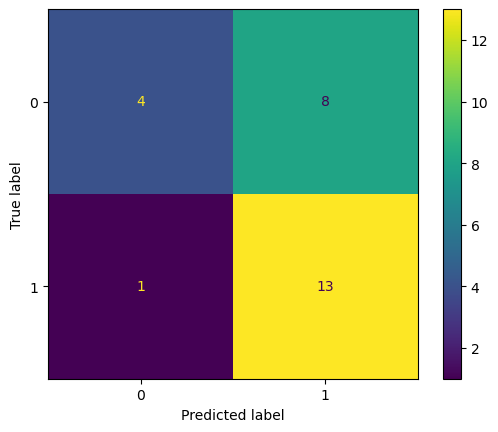

### Feature Importance

,Feature,Importance
0,X1,0.515
5,X6,0.125
4,X5,0.122
3,X4,0.094
2,X3,0.080
1,X2,0.064


In [10]:
param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [2, 3, 5, 7],
    'min_child_weight': [2, 3, 5],
    'gamma': [0],
    'reg_alpha': [0.001, 0.01, 0.1],
    'reg_lambda': [0.1, 1, 10],
    'colsample_bytree': [0.6],
    'subsample': [0.8]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=29),
    param_grid,
    cv=5, 
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)

xgb_model = xgb_grid.best_estimator_

thresholds = np.arange(0, 1, 0.01)
accuracies = []
y_prob = xgb_model.predict_proba(x_test)[:, 1]
for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    accuracies.append(
        accuracy_score(y_test, y_pred)
    )
best_threshold = thresholds[np.argmax(accuracies)]
best_accuracy = max(accuracies)

y_pred = (y_prob >= best_threshold).astype(int)

display(Markdown('### XGB Classifier Report'))

print('Best Parameters:')
print(xgb_grid.best_params_)

print("Best Threshold:", best_threshold)
if best_threshold < 0.1 or best_threshold > 0.9:
    display(Markdown('### ******BAD THRESHOLD******'))

print('Training Data Accuracy:')
print(round(xgb_model.score(x_train,y_train), 2))
print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)